# QSVT Linear Solver (2×2 System with Chebyshev Polynomial)

In this notebook we build a **non-trivial** QSVT-based linear solver:

- the matrix $A$ is **not** its own inverse,
- we use a **degree-3 Chebyshev polynomial** as the QSVT polynomial,
- on the actual eigenvalues of $A$, this polynomial behaves like an inverse
  up to an overall constant factor, which disappears after normalization.

This gives a genuine example where:

- $A^{-1} \ne A$,
- the QSVT polynomial has degree greater than 1,
- the QSVT solution matches the classical inverse solution **in direction**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qsvt.polynomials import (
    chebyshev_t3,
    eval_polynomial,
    is_bounded_on_interval,
    polynomial_degree,
    polynomial_parity,
)
from qsvt.qsvt import (
    apply_qsvt_to_embedded_vector,
    qsvt_top_left_block,
)

## 1. Define the linear system

We choose the diagonal matrix

$$
A = \mathrm{diag}(-0.5,\ 0.5),
$$

with eigenvalues

$$
\lambda_0 = -0.5, \qquad \lambda_1 = 0.5.
$$

Its inverse is

$$
A^{-1} = \mathrm{diag}(-2,\ 2),
$$

so this is no longer the trivial involutory case.

We choose

$$
\vec{b} = \frac{1}{\sqrt{2}}
\begin{pmatrix}
1 \\ 1
\end{pmatrix},
$$

so both eigencomponents are equally weighted.

In [2]:
A = np.array([[-0.5, 0.0], [0.0, 0.5]], dtype=float)
b = np.array([1.0 / np.sqrt(2), 1.0 / np.sqrt(2)], dtype=float)

eigvals, eigvecs = np.linalg.eigh(A)

x_true = np.linalg.solve(A, b)
x_true_normalized = x_true / np.linalg.norm(x_true)

print("A =")
print(A)
print("Eigenvalues of A:", eigvals)
print("b =", b)
print("True inverse solution x_true = A^{-1} b =", x_true)
print("True inverse solution (normalized) =", x_true_normalized)

A =
[[-0.5  0. ]
 [ 0.   0.5]]
Eigenvalues of A: [-0.5  0.5]
b = [0.70710678 0.70710678]
True inverse solution x_true = A^{-1} b = [-1.41421356  1.41421356]
True inverse solution (normalized) = [-0.70710678  0.70710678]


Since

$$
A^{-1} b
=
\frac{1}{\sqrt{2}}
\begin{pmatrix}
-2 \\ 2
\end{pmatrix},
$$

the normalized inverse solution points in the direction

$$
\begin{pmatrix}
-1 \\ 1
\end{pmatrix}.
$$

## 2. Target inverse behaviour on the spectrum

In the eigenbasis of $A$, a true inverse acts as

$$
b_i \longmapsto \frac{1}{\lambda_i} b_i.
$$

Here:

- $\frac{1}{\lambda_0} = -2$,
- $\frac{1}{\lambda_1} = 2$.

So up to an overall scale, the inverse multiplies components by

$$
[-2,\ 2] \propto [-1,\ 1].
$$

We therefore want a bounded polynomial $P(x)$ such that on the actual
eigenvalues,

$$
P(\lambda_i) \propto \frac{1}{\lambda_i}.
$$

## 3. Chebyshev polynomial $T_3(x)$

We use the third Chebyshev polynomial of the first kind:

$$
T_3(x) = 4x^3 - 3x.
$$

It is:

- odd,
- bounded on $[-1,1]$,
- a natural low-degree polynomial for QSVT examples.

In [3]:
poly = np.array([0.0, -3.0, 0.0, 4.0], dtype=float)

print("Polynomial coefficients:", poly)
print("Polynomial degree:", polynomial_degree(poly))
print("Polynomial parity:", polynomial_parity(poly))
print(
    "Bounded on [-1,1]:",
    is_bounded_on_interval(poly, lower=-1.0, upper=1.0, bound=1.0),
)

print()
print("T3(-0.5) =", chebyshev_t3(-0.5))
print("T3( 0.5) =", chebyshev_t3(0.5))

inv_eigs = 1.0 / eigvals
print("\nInverse eigenvalues 1/lambda:", inv_eigs)

ratio_T3 = chebyshev_t3(eigvals[0]) / chebyshev_t3(eigvals[1])
ratio_inv = inv_eigs[0] / inv_eigs[1]

print("\nRatio T3(lambda0) / T3(lambda1) =", ratio_T3)
print("Ratio (1/lambda0) / (1/lambda1) =", ratio_inv)

Polynomial coefficients: [ 0. -3.  0.  4.]
Polynomial degree: 3
Polynomial parity: odd
Bounded on [-1,1]: True

T3(-0.5) = 1.0
T3( 0.5) = -1.0

Inverse eigenvalues 1/lambda: [-2.  2.]

Ratio T3(lambda0) / T3(lambda1) = -1.0
Ratio (1/lambda0) / (1/lambda1) = -1.0


On this spectrum:

- $T_3(-0.5) = 1$,
- $T_3(0.5) = -1$,

so

$$
T_3(\lambda_i) \propto \frac{1}{\lambda_i}
$$

on the two eigenvalues of this example.

That is enough for the transformed vector to match the inverse solution
**in direction** after normalization.

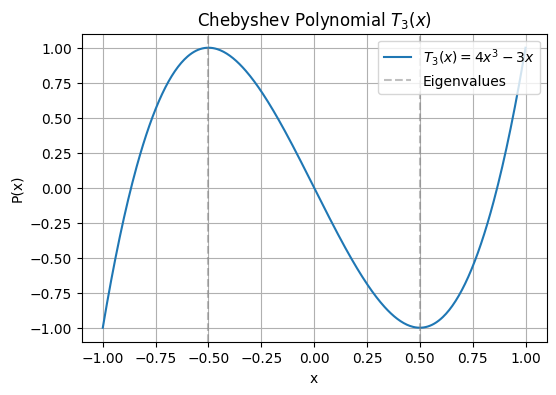

In [4]:
xs = np.linspace(-1.0, 1.0, 400)

plt.figure(figsize=(6, 4))
plt.plot(xs, eval_polynomial(poly, xs), label=r"$T_3(x)=4x^3-3x$")
plt.axvline(-0.5, color="grey", linestyle="--", alpha=0.5, label="Eigenvalues")
plt.axvline(0.5, color="grey", linestyle="--", alpha=0.5)
plt.xlabel("x")
plt.ylabel("P(x)")
plt.title("Chebyshev Polynomial $T_3(x)$")
plt.grid(True)
plt.legend()
plt.show()

## 4. Compute the QSVT-transformed block

We now compute the QSVT-transformed block $P(A)$ using the package helper
`qsvt_top_left_block`.

For a 2×2 matrix, embedding-based block encoding uses a 4×4 unitary, so we
pass two wires explicitly.

In [5]:
encoding_wires = [0, 1]
wire_order = [0, 1]

P_of_A = qsvt_top_left_block(
    A,
    poly,
    encoding_wires=encoding_wires,
    wire_order=wire_order,
)

print("QSVT top-left block P(A):")
print(np.round(P_of_A, 6))

P_A_direct = np.diag(eval_polynomial(poly, np.diag(A)))
print("\nDirect P(A):")
print(np.round(P_A_direct, 6))

QSVT top-left block P(A):
[[ 1.+1.e-06j  0.+0.e+00j]
 [ 0.+0.e+00j -1.-1.e-06j]]

Direct P(A):
[[ 1.  0.]
 [ 0. -1.]]


The QSVT-transformed block should match the direct polynomial transform
$P(A)$ up to numerical precision.

## 5. QSVT solution

We now apply the QSVT-transformed operator to $b$ using the package helper
`apply_qsvt_to_embedded_vector`.

Since $P(\lambda)$ and $1/\lambda$ agree up to an overall scalar on the
spectrum of $A$, the normalized QSVT output should match the normalized
classical inverse solution direction.

In [6]:
x_qsvt = apply_qsvt_to_embedded_vector(
    A,
    b,
    poly,
    encoding_wires=encoding_wires,
    wire_order=wire_order,
)

x_qsvt_normalized = x_qsvt / np.linalg.norm(x_qsvt)

print("QSVT-based solution (normalized) =", x_qsvt_normalized)
print("True inverse solution (normalized) =", x_true_normalized)

QSVT-based solution (normalized) = [ 0.70710678+9.99988939e-07j -0.70710678-9.99988939e-07j]
True inverse solution (normalized) = [-0.70710678  0.70710678]


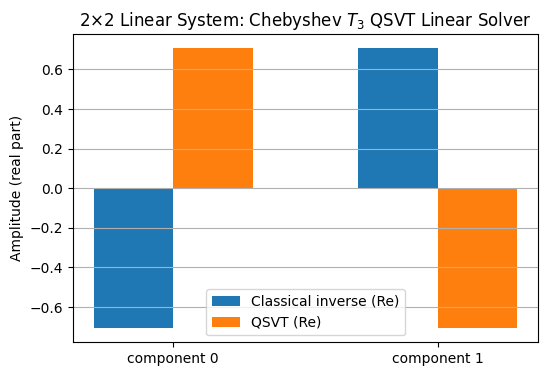

In [7]:
labels = ["component 0", "component 1"]

plt.figure(figsize=(6, 4))
plt.bar(
    np.arange(2) - 0.15,
    np.real(x_true_normalized),
    width=0.3,
    label="Classical inverse (Re)",
)
plt.bar(
    np.arange(2) + 0.15,
    np.real(x_qsvt_normalized),
    width=0.3,
    label="QSVT (Re)",
)
plt.xticks(np.arange(2), labels)
plt.ylabel("Amplitude (real part)")
plt.title("2×2 Linear System: Chebyshev $T_3$ QSVT Linear Solver")
plt.grid(True, axis="y")
plt.legend()
plt.show()

## 6. Summary

In this notebook we built a non-trivial QSVT-based linear solver:

- $A = \mathrm{diag}(-0.5, 0.5)$ is not involutory, so $A^{-1} \ne A$,
- we used the degree-3 Chebyshev polynomial

$$
T_3(x) = 4x^3 - 3x,
$$

- on the actual eigenvalues of $A$, this polynomial reproduces the same
  relative scaling as $1/x$,
- therefore the QSVT-transformed vector matches the classical inverse
  solution **in direction** after normalization.

This is a useful minimal example of an inverse-like QSVT polynomial acting on
a non-trivial spectrum.